# Sectoral INEN energy demand recalibration for Libya

This notebook takes a `sisepuede_raw_inputs_*` CSV and adjusts the **initial per-sector intensities** to values that are plausible for Libya 2023. The total lands around ~75 PJ: the 13 NDC sectors sum to ~60 PJ, plus `rubber_and_leather` **renamed as "Water"** carrying the full Libyan water-supply electric demand (~15 PJ in 2023) on a curve imported from an external water-energy model.

## Adjustments

Based on plausibility analysis against Libya's real industrial capacity:

| Sector | Target (PJ) | Decision | Reason |
|---|---:|---|---|
| Metals | **15.0** | ↓ from ~24 | LISCO Misrata operates at ~0.5–0.8 Mt steel/yr post‑2011, not its 1.3 Mt nameplate capacity |
| Mining | **0.4** | ↓ from ~2 | Non‑O&G Libyan mining is marginal (gypsum, limestone, salt); possible overlap with FGTV |
| Lime & carbonite | 21.22 | keep | Represents clinker calcination for 5–8 Mt cement annually |
| Chemicals | 5.90 | keep | Reflects reduced post‑conflict operation of the Marsa el‑Brega complex |
| Agriculture & livestock | 7.52 | keep | Great Man‑Made River pumping + deep wells in desert climate |
| Other manuf. | 7.86 | keep | Food & beverages + misc. (Libya's 2nd largest manufacturing segment) |
| Cement | 1.06 | keep | Electric fraction (thermal process lives under lime_and_carbonite) |
| **Rubber & leather ≡ "Water"** ⚡ | **year-by-year curve** | **HYPOTHETICAL** | **100% electric load following the BAU trajectory from the Libya water-energy model (row 19, sheet `Energy`). 15.17 PJ at 2020 → 14.09 PJ at 2050.** |
| Textiles / Paper / Plastic / Glass / Electronics / Wood | current value | keep | Minor industries with magnitudes already defensible |

## Adjustment logic

INEN demand per sector is computed as

$$\text{demand}_{c,t} = \bigl(\text{prod}_{c,t}\cdot I^{prod}_{c,0} + \text{gdp}_t\cdot I^{gdp}_{c,0}\bigr)\;\times\; \text{scalar}_{c,t}$$

Two calibration paths depending on sector type:

**A. Single-year anchor (13 NDC sectors).** For each sector we compute `factor_c = target_c / current_demand_c,2023` and multiply the `consumpinit_inen_energy_*_{sector}` column of the base CSV by that factor, including the `recycled_*` variant when present. `scalar_inen_energy_demand_*` is left untouched because the `TX:INEN:INC_EFFICIENCY_PRODUCTION_*` transformation overrides it under the Unconditional/Conditional strategies.

**B. Year-by-year trajectory (`rubber_and_leather` ≡ "Water").** For sectors in `SECTOR_TRAJECTORIES_PJ`, we overwrite `scalar_inen_energy_demand_{sector}` year-by-year so that

$$\text{demand}_{c,t}\text{(final)} = \text{target}_{c,t}\text{(trajectory)}$$

exactly. Formally we solve

$$\text{scalar}_{\text{new}}(t) \;=\; \frac{\text{target}(t)\cdot\text{scalar}_{\text{baseline}}(t)}{D_{\text{post-calibration}}(t)}$$

where $D_{\text{post-calibration}}$ is the demand produced by the INEN model after the sector's fuel mix has been forced to 100% electricity and its production has been boosted (step 2a below).

Sectors in `ELECTRICITY_ONLY_SECTORS` additionally get a **fuel mix override**: `frac_inen_energy_{sector}_electricity = 1.0` and the remaining 12 fuel fractions = `0.0` across all years, so their demand materializes 100% as electric load.

## Parameters

In [21]:
# Path to the base CSV we want to recalibrate
BASE_INPUT_CSV = "../../input_data/sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv"

# Output path for the recalibrated CSV
OUT_INPUT_CSV  = "../../input_data/sisepuede_raw_inputs_recalibrated_electricity_demand.csv"

# 2023 target INEN demand (PJ) per sector — plausibility analysis for Libya.
# rubber_and_leather is handled separately via SECTOR_TRAJECTORIES_PJ (year-by-year curve,
# not a single-year target), so it is NOT listed here.

SECTOR_TARGETS_2023 = {
    'agriculture_and_livestock':    9.5,   # keep — GMMR pumping + deep wells in desert climate
    'cement':                       1.06,   # keep — electric fraction (thermal lives in lime_and_carbonite)
    'chemicals':                    10.5,   # keep — reflects reduced post-2011 operation (Marsa el-Brega)
    'electronics':                  0.013,  # keep — Libya does not manufacture electronics
    'glass':                        0.142,  # keep — minor glass industry
    'lime_and_carbonite':           25.0,  # keep — clinker calcination for 5–8 Mt of cement
    'metals':                       20.0,   # ADJUST ↓ from ~24 PJ — LISCO at real 2023 operation (~0.5–0.8 Mt steel)
    'mining':                       0.4,    # ADJUST ↓ from ~2 PJ — marginal non-O&G mining (gypsum, limestone, salt)
    'other_product_manufacturing':  10.0,   # keep — food/beverages + misc.
    'paper':                        0.194,  # keep — conversion/recycling only
    'plastic':                      0.224,  # keep — conversion only (cracking lives in chemicals)
    'textiles':                     0.521,  # keep — residual textile industry
    'wood':                         0.012,  # keep — Libya has no wood industry
}

# Year-by-year target trajectories (PJ/yr) for sectors whose demand is shaped by
# an external model rather than a 2023 anchor. Sectors listed here are calibrated by
# overwriting their scalar_inen_energy_demand_{sector} column, so the per-year demand
# matches the curve exactly.
#
# rubber_and_leather is renamed as "Water" in the analysis: it represents the electricity
# demand of Libya's water supply system (groundwater + GMMR pipeline + recycled water).
# Source: row 19 (sheet 'Energy', label "BAU") of
#   ssp_modeling/input_data/reference/Libya_Water_Energy_Model_2020-2050-v6_final_cleanup.xlsx
# 2015–2019 extrapolated flat at the 2020 value (BAU is nearly flat on that side).

WATER_BAU_TRAJECTORY_PJ = {
    2020: 13.61, 2021: 13.80, 2022: 13.99, 2023: 14.19,
    2024: 14.40, 2025: 14.60, 2026: 14.82, 2027: 15.04,
    2028: 15.27, 2029: 15.49, 2030: 15.73, 2031: 15.97,
    2032: 16.21, 2033: 16.46, 2034: 16.71, 2035: 16.97,
    2036: 17.24, 2037: 17.51, 2038: 17.78, 2039: 18.07,
    2040: 18.36, 2041: 18.65, 2042: 18.95, 2043: 19.26,
    2044: 19.57, 2045: 19.90, 2046: 20.22, 2047: 20.56,
    2048: 20.90, 2049: 21.25, 2050: 21.61,
}

SECTOR_TRAJECTORIES_PJ = {
    'rubber_and_leather': WATER_BAU_TRAJECTORY_PJ,
}

# Sectors forced to demand ONLY electricity:
# frac_inen_energy_{sector}_electricity = 1.0 and all other fractions = 0.0 for every year
# (also applied to the recycled_{sector} variant when present).
ELECTRICITY_ONLY_SECTORS = ['rubber_and_leather']

# Base year (t=0) of the input
BASE_YEAR = 2015

# Year where we measure / fix the single-year targets
TARGET_YEAR = 2023

# Target total electricity consumption (PJ) at TARGET_YEAR, summed across every
# energy_consumption_electricity_* column in the INEN-only run. SCOE is calibrated in
# §5 so the grand total hits this number without touching other subsectors.
TOTAL_ELEC_TARGET_2023 = 165.99*1.3

# If True, run the full pipeline with the 3 strategies at the end
RUN_VERIFICATION = True

# Input region
REGION = "libya"

In [22]:
import os, sys, pathlib, warnings, logging
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

HERE = pathlib.Path(os.getcwd())
sys.path.insert(0, str(HERE.parent))
from utils.logger_utils import setup_clean_logger, mute_external_loggers
logger = setup_clean_logger('recalib', logging.INFO)
mute_external_loggers(['sisepuede'])

## 1. Measure current INEN demand on the base input

Run the **INEN model only** (no NemoMod) on the base input to obtain per-sector demand at 2023. This current demand is the denominator used to compute the sectoral factor in §2.

In [23]:
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
from ssp_transformations_handler.GeneralUtils import GeneralUtils

_EXAMPLES = sxl.SISEPUEDEExamples()

# Chart categories: the 13 NDC sectors + rubber_and_leather (hypothetical electric load)
CHART_CATS = [
    'cement', 'chemicals', 'electronics', 'glass', 'lime_and_carbonite',
    'metals', 'mining', 'other_product_manufacturing', 'paper', 'plastic',
    'rubber_and_leather', 'textiles', 'wood',
]

def run_inen_only(csv_path: str, y0: int = BASE_YEAR, y1: int = 2050) -> pd.DataFrame:
    """Run only the EnergyConsumption (INEN) model, no NemoMod."""
    df_raw = pd.read_csv(csv_path)
    fs = sfs.SISEPUEDEFileStructure(initialize_directories=False)
    key_tp, key_year = fs.model_attributes.dim_time_period, fs.model_attributes.field_dim_year
    years = np.arange(y0, y1 + 1).astype(int)
    att_tp = att.AttributeTable(
        pd.DataFrame({key_tp: range(len(years)), key_year: years}), key_tp,
    )
    fs.model_attributes.update_dimensional_attribute_table(att_tp)
    matt = fs.model_attributes
    models = sm.SISEPUEDEModels(
        matt, allow_electricity_run=False,
        fp_julia=fs.dir_jl, fp_nemomod_reference_files=fs.dir_ref_nemo,
        initialize_julia=False,
    )
    df_ex = _EXAMPLES('input_data_frame')
    df = GeneralUtils().add_missing_cols(df_ex, df_raw.copy())
    df['region'] = REGION
    df = df[df['year'] <= y1]
    df_out = models.project(df, include_electricity_in_energy=False)
    df_out['year'] = df_out['time_period'].apply(lambda t: y0 + int(t))
    return df_out

df_out = run_inen_only(BASE_INPUT_CSV)
chart_cols = [f'energy_demand_inen_{c}' for c in CHART_CATS]
current_2023 = df_out.loc[df_out['year'] == TARGET_YEAR, chart_cols].sum(axis=1).iloc[0]
current_2050 = df_out.loc[df_out['year'] == 2050, chart_cols].sum(axis=1).iloc[0]
print(f'Current INEN demand on base input:')
print(f'  {TARGET_YEAR}: {current_2023:.2f} PJ')
print(f'  2050:         {current_2050:.2f} PJ')

No missing columns to add.
Current INEN demand on base input:
  2023: 73.95 PJ
  2050:         132.18 PJ


## 2. Apply calibration

Four steps executed in order in the same cell:

**2a. Production rescue.** For sectors whose baseline 2023 demand is exactly 0 (because the WASO recycling offset cancels virgin IPPU production), bump `prodinit_ippu_{sector}_tonne` by `PRODINIT_BOOST` so net production becomes positive and downstream scaling is well-defined.

**2b. Electricity-only fuel mix.** For each sector in `ELECTRICITY_ONLY_SECTORS`, set `frac_inen_energy_{sector}_electricity = 1.0` and the other 12 fractions = `0.0` across ALL years of the CSV. Applied to the primary variant and to `recycled_{sector}` when present.

**2c. Single-year consumpinit factor (sectors in `SECTOR_TARGETS_2023`).** For each sector `c` compute $f_c = \text{target}_{c,2023} / \text{current demand}_{c,2023}$ and multiply the `consumpinit_inen_energy_*_{c}` column(s) by that factor. Sectors listed in `SECTOR_TRAJECTORIES_PJ` are **excluded** from this loop — their trajectory is shaped via scalar, not consumpinit.

**2d. Per-year scalar for trajectory sectors (`SECTOR_TRAJECTORIES_PJ`).** Re-run the INEN model on the post-2c CSV to obtain $D_{\text{post-calibration}}(t)$ for every year, then write

$$\text{scalar}_{\text{new}}(t) \;=\; \text{target}(t)\cdot\text{scalar}_{\text{baseline}}(t)\,/\,D_{\text{post-calibration}}(t)$$

into `scalar_inen_energy_demand_{sector}`. Years outside the trajectory domain (e.g. 2015–2019 for the Water model which starts in 2020) are extrapolated flat at the nearest boundary value.

Sector → intensity column mapping (path A):

| Sector | Primary column | Recycled column |
|---|---|---|
| agriculture_and_livestock | `consumpinit_inen_energy_total_pj_agriculture_and_livestock` | — |
| cement | `consumpinit_inen_energy_tj_per_tonne_production_cement` | — |
| chemicals | `consumpinit_inen_energy_tj_per_tonne_production_chemicals` | — |
| electronics | `consumpinit_inen_energy_tj_per_tonne_production_electronics` | — |
| glass | `..._glass` | `..._recycled_glass` |
| lime_and_carbonite | `..._lime_and_carbonite` | — |
| metals | `..._metals` | `..._recycled_metals` |
| mining | `..._mining` | — |
| other_product_manufacturing | `consumpinit_inen_energy_tj_per_mmm_gdp_other_product_manufacturing` | — |
| paper | `..._paper` | `..._recycled_paper` |
| plastic | `..._plastic` | `..._recycled_plastic` |
| textiles | `..._textiles` | `..._recycled_textiles` |
| wood | `..._wood` | `..._recycled_wood` |

Trajectory sector (path B):

| Sector | Scalar column | Trajectory source |
|---|---|---|
| **rubber_and_leather** ⚡ | `scalar_inen_energy_demand_rubber_and_leather` | `WATER_BAU_TRAJECTORY_PJ` (row 19, sheet `Energy`) |

In [24]:
# Sector → consumpinit_inen_energy_* columns (primary + recycled when present).
# Only sectors calibrated through the single-year target path (2c) need entries here.
SECTOR_COLS = {
    'agriculture_and_livestock': ['consumpinit_inen_energy_total_pj_agriculture_and_livestock'],
    'cement':                    ['consumpinit_inen_energy_tj_per_tonne_production_cement'],
    'chemicals':                 ['consumpinit_inen_energy_tj_per_tonne_production_chemicals'],
    'electronics':               ['consumpinit_inen_energy_tj_per_tonne_production_electronics'],
    'glass':                     ['consumpinit_inen_energy_tj_per_tonne_production_glass',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_glass'],
    'lime_and_carbonite':        ['consumpinit_inen_energy_tj_per_tonne_production_lime_and_carbonite'],
    'metals':                    ['consumpinit_inen_energy_tj_per_tonne_production_metals',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_metals'],
    'mining':                    ['consumpinit_inen_energy_tj_per_tonne_production_mining'],
    'other_product_manufacturing': ['consumpinit_inen_energy_tj_per_mmm_gdp_other_product_manufacturing'],
    'paper':                     ['consumpinit_inen_energy_tj_per_tonne_production_paper',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_paper'],
    'plastic':                   ['consumpinit_inen_energy_tj_per_tonne_production_plastic',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_plastic'],
    'textiles':                  ['consumpinit_inen_energy_tj_per_tonne_production_textiles',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_textiles'],
    'wood':                      ['consumpinit_inen_energy_tj_per_tonne_production_wood',
                                  'consumpinit_inen_energy_tj_per_tonne_production_recycled_wood'],
}

# Validate the single-year targets and the column map match exactly.
assert set(SECTOR_TARGETS_2023) == set(SECTOR_COLS), \
    f'Sector misalignment: targets-cols={set(SECTOR_TARGETS_2023)-set(SECTOR_COLS)} '\
    f'cols-targets={set(SECTOR_COLS)-set(SECTOR_TARGETS_2023)}'
# Trajectory sectors must NOT appear in the single-year loop.
_dup = set(SECTOR_TRAJECTORIES_PJ) & set(SECTOR_TARGETS_2023)
assert not _dup, f'Sectors cannot be both single-year and trajectory: {_dup}'

# All sectors we measure (combined set — used for baseline snapshot and reporting).
ALL_SECTORS = list(SECTOR_TARGETS_2023) + list(SECTOR_TRAJECTORIES_PJ)

# Baseline 2023 demand per sector (measured in cell_measure over the untouched base CSV).
row_2023_base = df_out.loc[df_out['year'] == TARGET_YEAR].iloc[0]
current_base = {s: float(row_2023_base[f'energy_demand_inen_{s}']) for s in ALL_SECTORS}

df_in = pd.read_csv(BASE_INPUT_CSV)
missing = [c for cols in SECTOR_COLS.values() for c in cols if c not in df_in.columns]
assert not missing, f'Missing columns in base CSV: {missing}'

# --- 2a. Rescue sectors with zero IPPU production -------------------------------------
# Some sectors (e.g. rubber_and_leather on the Libya input) come out with demand = 0 because
# the virgin IPPU production is cancelled by the WASO-derived recycling offset. Bump
# prodinit_ippu_{sector}_tonne so net production exceeds the offset and demand > 0;
# the exact value does not matter because the subsequent scalar/consumpinit step rescales it.
PRODINIT_BOOST = 100.0
zero_demand_sectors = [s for s, v in current_base.items() if v == 0.0]
for sector in zero_demand_sectors:
    col = f'prodinit_ippu_{sector}_tonne'
    if col in df_in.columns:
        df_in[col] = df_in[col] * PRODINIT_BOOST
        print(f'  prodinit boost {PRODINIT_BOOST:g}x -> {col} (sector baseline = 0 PJ)')

# --- 2b. Force fuel mix = 100% electricity for sectors in ELECTRICITY_ONLY_SECTORS -----
for sector in ELECTRICITY_ONLY_SECTORS:
    for variant in [sector, f'recycled_{sector}']:
        prefix = f'frac_inen_energy_{variant}_'
        frac_cols = [c for c in df_in.columns if c.startswith(prefix)]
        if not frac_cols:
            continue
        elec_col = f'{prefix}electricity'
        assert elec_col in frac_cols, f'Missing column {elec_col} in base CSV'
        for c in frac_cols:
            df_in[c] = 1.0 if c == elec_col else 0.0
        print(f'  fuel mix -> 100% electricity applied to {variant} ({len(frac_cols)} cols)')

# If we touched prodinit or fractions, re-run INEN to capture the post-boost demand.
if zero_demand_sectors or ELECTRICITY_ONLY_SECTORS:
    df_in.to_csv(OUT_INPUT_CSV, index=False)
    df_measure_boosted = run_inen_only(OUT_INPUT_CSV)
    row_boosted = df_measure_boosted.loc[df_measure_boosted['year'] == TARGET_YEAR].iloc[0]
    current_by_sector = {s: float(row_boosted[f'energy_demand_inen_{s}']) for s in ALL_SECTORS}
else:
    current_by_sector = dict(current_base)

# --- 2c. Single-year target: apply consumpinit factor to the 13 NDC sectors -----------
summary_rows = []
for sector, target in SECTOR_TARGETS_2023.items():
    current = current_by_sector[sector]
    factor = target / current if current > 0 else 1.0
    for col in SECTOR_COLS[sector]:
        df_in[col] = df_in[col] * factor
    summary_rows.append({
        'sector':        sector,
        'baseline_2023': round(current_base[sector], 4),
        'boosted_2023':  round(current, 4),
        'target_2023':   round(target, 4),
        'factor':        round(factor, 4),
        'n_cols':        len(SECTOR_COLS[sector]),
        'path':          'consumpinit@2023',
        'elec_only':     sector in ELECTRICITY_ONLY_SECTORS,
    })

# --- 2d. Trajectory calibration: overwrite scalar_inen_energy_demand_{sector} ---------
# We need D_post(t) for trajectory sectors _after_ (2a + 2b + 2c) are applied. Write the
# partially-recalibrated CSV, run INEN once, then compute the new scalar per year.
if SECTOR_TRAJECTORIES_PJ:
    df_in.to_csv(OUT_INPUT_CSV, index=False)
    df_post_2c = run_inen_only(OUT_INPUT_CSV)
    years_model = df_post_2c['year'].astype(int).tolist()
    years_model_sorted = sorted(set(years_model))

    def _traj_value(traj: dict, year: int) -> float:
        """Flat extrapolation outside [min(years), max(years)]."""
        ymin, ymax = min(traj), max(traj)
        if year <= ymin:
            return traj[ymin]
        if year >= ymax:
            return traj[ymax]
        return traj[year]

    for sector, traj in SECTOR_TRAJECTORIES_PJ.items():
        scalar_col = f'scalar_inen_energy_demand_{sector}'
        assert scalar_col in df_in.columns, f'Missing scalar column {scalar_col}'

        # Align years: df_in rows ↔ model output rows (both share the region's year column)
        df_in_sorted = df_in.sort_values('year').reset_index(drop=True)
        d_post = df_post_2c.set_index('year')[f'energy_demand_inen_{sector}']

        scalar_base = df_in_sorted.set_index('year')[scalar_col]
        scalar_new = {}
        for y in df_in_sorted['year'].astype(int):
            target_y  = _traj_value(traj, int(y))
            d_post_y  = float(d_post.loc[y]) if y in d_post.index else 0.0
            scalar_b  = float(scalar_base.loc[y])
            if d_post_y <= 0.0:
                raise RuntimeError(
                    f'{sector}: post-2c demand is {d_post_y:.6f} PJ at {y} — '
                    f'cannot shape trajectory via scalar (need > 0).'
                )
            scalar_new[int(y)] = target_y * scalar_b / d_post_y

        # Write back into df_in using the year column as key
        df_in[scalar_col] = df_in['year'].astype(int).map(scalar_new).astype(float)

        # Trajectory summary row (target at 2023 for comparison; per-year check in §3)
        target_2023 = _traj_value(traj, TARGET_YEAR)
        d_post_2023 = float(d_post.loc[TARGET_YEAR])
        summary_rows.append({
            'sector':        sector,
            'baseline_2023': round(current_base[sector], 4),
            'boosted_2023':  round(d_post_2023, 4),
            'target_2023':   round(target_2023, 4),
            'factor':        round(target_2023 / d_post_2023, 4),
            'n_cols':        1,  # scalar column
            'path':          'scalar@year',
            'elec_only':     sector in ELECTRICITY_ONLY_SECTORS,
        })
        print(f'  scalar trajectory written to {scalar_col} '
              f'({len(scalar_new)} years, {min(scalar_new.values()):.4f}..{max(scalar_new.values()):.4f})')

summary = pd.DataFrame(summary_rows).sort_values('sector').reset_index(drop=True)
print()
print(summary.to_string(index=False))
print(f"\nSum baseline_2023: {summary['baseline_2023'].sum():.2f} PJ")
print(f"Sum target_2023:   {summary['target_2023'].sum():.2f} PJ")

os.makedirs(os.path.dirname(OUT_INPUT_CSV), exist_ok=True)
df_in.to_csv(OUT_INPUT_CSV, index=False)
print(f'\nWrote recalibrated input to: {OUT_INPUT_CSV}')

  fuel mix -> 100% electricity applied to rubber_and_leather (13 cols)
  fuel mix -> 100% electricity applied to recycled_rubber_and_leather (13 cols)
No missing columns to add.
No missing columns to add.
  scalar trajectory written to scalar_inen_energy_demand_rubber_and_leather (36 years, 0.0192..0.0324)

                     sector  baseline_2023  boosted_2023  target_2023  factor  n_cols             path  elec_only
  agriculture_and_livestock          7.520         7.520        9.500  1.2633       1 consumpinit@2023      False
                     cement          1.060         1.060        1.060  1.0000       1 consumpinit@2023      False
                  chemicals          5.900         5.900       10.500  1.7797       1 consumpinit@2023      False
                electronics          0.013         0.013        0.013  1.0000       1 consumpinit@2023      False
                      glass          0.142         0.142        0.142  1.0000       2 consumpinit@2023      False
       

## 3. Verify

Re-run the INEN model on the recalibrated input and confirm:

1. **Single-year sectors** — every sector in `SECTOR_TARGETS_2023` lands within ±1% of its 2023 target.
2. **Trajectory sectors** — for every sector in `SECTOR_TRAJECTORIES_PJ`, the per-year demand matches the target trajectory within ±1% across all years that belong to the trajectory's domain.
3. **Electricity-only sectors** — ≥99% of INEN consumption materializes as electricity; the `frac_inen_energy_*` columns are written as `electricity=1`, others=`0` for every year.

In [25]:
df_out_new = run_inen_only(OUT_INPUT_CSV)
row_new_2023 = df_out_new.loc[df_out_new['year'] == TARGET_YEAR].iloc[0]

# --- 3.1 Single-year sectors: ±1% at TARGET_YEAR ---------------------------------------
verify_rows = []
for sector, target in SECTOR_TARGETS_2023.items():
    new = float(row_new_2023[f'energy_demand_inen_{sector}'])
    dev_pct = (new - target) / target * 100 if target > 0 else 0.0
    verify_rows.append({
        'sector':        sector,
        'baseline_2023': round(current_base[sector], 4),
        'target_2023':   round(target, 4),
        'new_2023':      round(new, 4),
        'dev_%':         round(dev_pct, 2),
    })
verify = pd.DataFrame(verify_rows).sort_values('sector').reset_index(drop=True)
print('--- Single-year sectors (target at 2023) ---')
print(verify.to_string(index=False))

max_dev_single = verify['dev_%'].abs().max()
assert max_dev_single < 1.0, (
    f'Some single-year sector deviated >1% from target at {TARGET_YEAR} '
    f'(max |dev| = {max_dev_single:.2f}%)'
)
print(f"\nOK - all single-year sectors within +/-1% (max |dev| = {max_dev_single:.2f}%).")

# --- 3.2 Trajectory sectors: per-year ±1% across the trajectory's domain --------------
for sector, traj in SECTOR_TRAJECTORIES_PJ.items():
    years_traj = sorted(traj)
    demand_by_year = df_out_new.set_index('year')[f'energy_demand_inen_{sector}']
    rows = []
    for y in years_traj:
        target_y = traj[y]
        new_y    = float(demand_by_year.loc[y]) if y in demand_by_year.index else float('nan')
        dev_pct  = (new_y - target_y) / target_y * 100 if target_y > 0 else 0.0
        rows.append({'year': y, 'target_PJ': round(target_y, 4),
                     'new_PJ': round(new_y, 4), 'dev_%': round(dev_pct, 3)})
    traj_df = pd.DataFrame(rows)
    print(f'\n--- Trajectory sector: {sector} (years {years_traj[0]}..{years_traj[-1]}) ---')
    # Show the 5 worst deviations plus the endpoints
    worst = traj_df.reindex(traj_df['dev_%'].abs().sort_values(ascending=False).index).head(5)
    endpoints = traj_df.iloc[[0, -1]]
    print('Endpoints:'); print(endpoints.to_string(index=False))
    print('Worst 5 deviations:'); print(worst.to_string(index=False))
    max_dev_traj = traj_df['dev_%'].abs().max()
    assert max_dev_traj < 1.0, (
        f'{sector}: some year deviated >1% from trajectory (max |dev| = {max_dev_traj:.3f}%)'
    )
    print(f'OK - {sector} matches trajectory within +/-1% (max |dev| = {max_dev_traj:.3f}%).')

# --- 3.3 Totals ------------------------------------------------------------------------
new_total_2023 = sum(
    float(row_new_2023[f'energy_demand_inen_{s}'])
    for s in (list(SECTOR_TARGETS_2023) + list(SECTOR_TRAJECTORIES_PJ))
)
target_total = sum(SECTOR_TARGETS_2023.values()) + sum(
    SECTOR_TRAJECTORIES_PJ[s][TARGET_YEAR]
    for s in SECTOR_TRAJECTORIES_PJ
    if TARGET_YEAR in SECTOR_TRAJECTORIES_PJ[s]
)
new_2050 = df_out_new.loc[df_out_new['year'] == 2050, chart_cols].sum(axis=1).iloc[0]
print(f"\nTotal {TARGET_YEAR}: {new_total_2023:.2f} PJ  (target sum {target_total:.2f} PJ)")
print(f"Total 2050:         {new_2050:.2f} PJ")

# --- 3.4 Electricity-only sectors: 100% electric consumption --------------------------
print()
for sector in ELECTRICITY_ONLY_SECTORS:
    total_dem  = float(row_new_2023[f'energy_demand_inen_{sector}'])
    elec_cons  = float(row_new_2023.get(f'energy_consumption_electricity_inen_{sector}', 0.0))
    total_cons = float(row_new_2023.get(f'energy_consumption_inen_{sector}', 0.0))
    print(f'  {sector}: demand={total_dem:.2f} PJ | electricity_consumption={elec_cons:.2f} PJ '
          f'| total_consumption={total_cons:.2f} PJ')
    if total_cons > 0:
        frac_elec = elec_cons / total_cons
        assert frac_elec > 0.99, f'{sector}: only {frac_elec*100:.2f}% consumed as electricity'
        print(f'    OK {frac_elec*100:.2f}% of INEN consumption materializes as electricity')

df_check = pd.read_csv(OUT_INPUT_CSV)
for sector in ELECTRICITY_ONLY_SECTORS:
    for variant in [sector, f'recycled_{sector}']:
        prefix = f'frac_inen_energy_{variant}_'
        frac_cols = [c for c in df_check.columns if c.startswith(prefix)]
        if not frac_cols:
            continue
        elec = df_check[f'{prefix}electricity']
        others = df_check[[c for c in frac_cols if c != f'{prefix}electricity']].sum(axis=1)
        assert (elec == 1.0).all(), f'{variant}: electricity != 1.0 in some year'
        assert (others == 0.0).all(), f'{variant}: non-electricity fuel > 0 in some year'
        print(f'    OK {variant} frac_inen_energy_*: electricity=1, others=0 in every year')

No missing columns to add.
--- Single-year sectors (target at 2023) ---
                     sector  baseline_2023  target_2023  new_2023  dev_%
  agriculture_and_livestock          7.520        9.500     9.500    0.0
                     cement          1.060        1.060     1.060   -0.0
                  chemicals          5.900       10.500    10.500   -0.0
                electronics          0.013        0.013     0.013   -0.0
                      glass          0.142        0.142     0.142   -0.0
         lime_and_carbonite         21.220       25.000    25.000   -0.0
                     metals         15.000       20.000    20.000   -0.0
                     mining          0.400        0.400     0.400   -0.0
other_product_manufacturing          7.860       10.000    10.000    0.0
                      paper          0.194        0.194     0.194    0.0
                    plastic          0.224        0.224     0.224   -0.0
                   textiles          0.521        0.

## 4. Total estimated electricity across all sectors

Sum every `energy_consumption_electricity_*` column in the INEN-only run to see the full electric load the energy model is projecting on the recalibrated input. This includes INEN (industry) plus any other energy subsector that ends up consuming electricity on this CSV (e.g. SCOE, TRNS, CCSQ when their columns are populated). NemoMod is **not** run in this notebook, so this is the demand-side view — not the supply-side dispatch.

In [26]:
import re

# All electricity-consumption columns produced by the INEN-only run.
# Pattern: energy_consumption_electricity_{subsector}_{category}
all_elec_cols = [c for c in df_out_new.columns if c.startswith('energy_consumption_electricity_')]
assert all_elec_cols, 'No energy_consumption_electricity_* columns found in df_out_new'

# Group columns by subsector token (inen, scoe, trns, ccsq, entc, fgtv, ...)
_rx = re.compile(r'^energy_consumption_electricity_([a-z]+)_')
subsector_cols: dict[str, list[str]] = {}
for c in all_elec_cols:
    m = _rx.match(c)
    if not m:
        continue
    subsector_cols.setdefault(m.group(1), []).append(c)

def _elec_by_subsector(df: pd.DataFrame, year: int) -> dict[str, float]:
    row = df.loc[df['year'] == year].iloc[0]
    return {ss: float(row[cols].sum()) for ss, cols in subsector_cols.items()}

years_report = [TARGET_YEAR, 2030, 2050]

# Per-subsector totals for the reporting years
subsector_rows = []
for ss in sorted(subsector_cols):
    row = {'subsector': ss, 'n_cols': len(subsector_cols[ss])}
    for y in years_report:
        row[f'elec_PJ_{y}'] = round(_elec_by_subsector(df_out_new, y)[ss], 4)
    subsector_rows.append(row)
sub_df = (
    pd.DataFrame(subsector_rows)
      .sort_values(f'elec_PJ_{TARGET_YEAR}', ascending=False)
      .reset_index(drop=True)
)

# Grand total across every electricity-consumption column
elec_total_by_year = df_out_new.set_index('year')[all_elec_cols].sum(axis=1)
totals = {y: float(elec_total_by_year.loc[y]) for y in years_report}

print(f'Electricity consumption by subsector (post-recalibration, INEN-only run):')
print(sub_df.to_string(index=False))

print(f'\nGrand total electricity consumption (all subsectors, {len(all_elec_cols)} cols):')
for y in years_report:
    print(f'  {y}: {totals[y]:.2f} PJ  ({totals[y]/3.6:.2f} TWh)')

Electricity consumption by subsector (post-recalibration, INEN-only run):
subsector  n_cols  elec_PJ_2023  elec_PJ_2030  elec_PJ_2050
     scoe       4       99.8802      120.2726      186.2711
     inen      22       30.6398       34.9983       48.5790
     trns      10        1.7434        3.8757       36.8168
     ccsq       2        0.0000        0.0000        0.0000

Grand total electricity consumption (all subsectors, 38 cols):
  2023: 132.26 PJ  (36.74 TWh)
  2030: 159.15 PJ  (44.21 TWh)
  2050: 271.67 PJ  (75.46 TWh)


## 5. Calibrate SCOE electricity to hit `TOTAL_ELEC_TARGET_2023`

After §3, SCOE (buildings heat + appliances) dominates total electricity at ~148 PJ, which pushes the grand total far above the Libya 2023 figure (~121.49 PJ). Scale **only the SCOE sector** via a single multiplicative factor on its 6 `consumpinit_scoe_*` columns (3 building types × {`heat_energy`, `elec_appliances`}) so that

$$\sum_{\text{subsectors}} \text{energy\_consumption\_electricity}(t_{2023}) \;=\; \text{TOTAL\_ELEC\_TARGET\_2023}$$

Since scaling is linear in `consumpinit`, SCOE's electric output scales by the same factor as SCOE's total demand. Other subsectors (INEN including the Water load, TRNS, CCSQ…) are **not touched**.

| SCOE column scaled | Building type |
|---|---|
| `consumpinit_scoe_gj_per_hh_residential_elec_appliances` | residential |
| `consumpinit_scoe_gj_per_hh_residential_heat_energy` | residential |
| `consumpinit_scoe_tj_per_mmmgdp_commercial_municipal_elec_appliances` | commercial/municipal |
| `consumpinit_scoe_tj_per_mmmgdp_commercial_municipal_heat_energy` | commercial/municipal |
| `consumpinit_scoe_tj_per_mmmgdp_other_se_elec_appliances` | other services |
| `consumpinit_scoe_tj_per_mmmgdp_other_se_heat_energy` | other services |

Note: scaling `consumpinit_scoe_*_heat_energy` also shrinks SCOE's non-electric heat (gas/diesel) proportionally, because heat fuel mix (`frac_scoe_heat_energy_*`) is unchanged. This is the intended behavior — we're rescaling Libya's SCOE footprint as a whole, anchored on the electric total.

In [27]:
# Current totals at TARGET_YEAR (from §4's df_out_new, which is the post-§3 run).
current_elec_total = float(df_out_new.set_index('year')[all_elec_cols].sum(axis=1).loc[TARGET_YEAR])
current_scoe_elec  = float(_elec_by_subsector(df_out_new, TARGET_YEAR).get('scoe', 0.0))
assert current_scoe_elec > 0, 'No SCOE electricity found in df_out_new'

# SCOE must absorb the overshoot on the grand total.
target_scoe_elec = current_scoe_elec - (current_elec_total - TOTAL_ELEC_TARGET_2023)
assert target_scoe_elec > 0, (
    f'Target infeasible: would require SCOE elec = {target_scoe_elec:.2f} PJ. '
    f'(current SCOE = {current_scoe_elec:.2f}, current total = {current_elec_total:.2f}, '
    f'target total = {TOTAL_ELEC_TARGET_2023:.2f})'
)
scoe_factor = target_scoe_elec / current_scoe_elec

SCOE_CONSUMPINIT_COLS = [
    'consumpinit_scoe_gj_per_hh_residential_elec_appliances',
    'consumpinit_scoe_gj_per_hh_residential_heat_energy',
    'consumpinit_scoe_tj_per_mmmgdp_commercial_municipal_elec_appliances',
    'consumpinit_scoe_tj_per_mmmgdp_commercial_municipal_heat_energy',
    'consumpinit_scoe_tj_per_mmmgdp_other_se_elec_appliances',
    'consumpinit_scoe_tj_per_mmmgdp_other_se_heat_energy',
]

df_in_final = pd.read_csv(OUT_INPUT_CSV)
missing = [c for c in SCOE_CONSUMPINIT_COLS if c not in df_in_final.columns]
assert not missing, f'Missing SCOE consumpinit columns: {missing}'
for col in SCOE_CONSUMPINIT_COLS:
    df_in_final[col] = df_in_final[col] * scoe_factor
df_in_final.to_csv(OUT_INPUT_CSV, index=False)

print(f'SCOE calibration:')
print(f'  current total electricity (all subsectors): {current_elec_total:.2f} PJ')
print(f'  current SCOE electricity:                   {current_scoe_elec:.2f} PJ')
print(f'  target total electricity (all subsectors):  {TOTAL_ELEC_TARGET_2023:.2f} PJ')
print(f'  target SCOE electricity:                    {target_scoe_elec:.2f} PJ')
print(f'  factor applied to {len(SCOE_CONSUMPINIT_COLS)} SCOE consumpinit cols: {scoe_factor:.4f}')

# --- Verify ----------------------------------------------------------------------------
df_post_scoe = run_inen_only(OUT_INPUT_CSV)
new_elec_by_year   = df_post_scoe.set_index('year')[all_elec_cols].sum(axis=1)
new_total_2023     = float(new_elec_by_year.loc[TARGET_YEAR])
new_scoe_2023      = float(_elec_by_subsector(df_post_scoe, TARGET_YEAR).get('scoe', 0.0))
dev_pct            = (new_total_2023 - TOTAL_ELEC_TARGET_2023) / TOTAL_ELEC_TARGET_2023 * 100

print(f'\nPost-calibration @ {TARGET_YEAR}:')
print(f'  SCOE electricity:  {new_scoe_2023:.2f} PJ  (was {current_scoe_elec:.2f})')
print(f'  Total electricity: {new_total_2023:.2f} PJ  (target {TOTAL_ELEC_TARGET_2023:.2f}, dev {dev_pct:+.3f}%)')
assert abs(dev_pct) < 1.0, f'Total elec at {TARGET_YEAR} deviated {dev_pct:.3f}% from target'
print(f'OK - total electricity matches target within +/-1%.')

# Per-subsector breakdown post-calibration
post_rows = []
for ss in sorted(subsector_cols):
    row = {'subsector': ss, 'n_cols': len(subsector_cols[ss])}
    for y in years_report:
        row[f'elec_PJ_{y}'] = round(_elec_by_subsector(df_post_scoe, y)[ss], 4)
    post_rows.append(row)
post_df = (
    pd.DataFrame(post_rows)
      .sort_values(f'elec_PJ_{TARGET_YEAR}', ascending=False)
      .reset_index(drop=True)
)
print('\nElectricity consumption by subsector (post-SCOE calibration):')
print(post_df.to_string(index=False))

print(f'\nGrand total electricity (post-SCOE calibration):')
for y in years_report:
    tot = float(new_elec_by_year.loc[y])
    print(f'  {y}: {tot:.2f} PJ  ({tot/3.6:.2f} TWh)')

SCOE calibration:
  current total electricity (all subsectors): 132.26 PJ
  current SCOE electricity:                   99.88 PJ
  target total electricity (all subsectors):  215.79 PJ
  target SCOE electricity:                    183.40 PJ
  factor applied to 6 SCOE consumpinit cols: 1.8362
No missing columns to add.

Post-calibration @ 2023:
  SCOE electricity:  183.40 PJ  (was 99.88)
  Total electricity: 215.79 PJ  (target 215.79, dev -0.000%)
OK - total electricity matches target within +/-1%.

Electricity consumption by subsector (post-SCOE calibration):
subsector  n_cols  elec_PJ_2023  elec_PJ_2030  elec_PJ_2050
     scoe       4      183.4038      220.8492      342.0381
     inen      22       30.6398       34.9983       48.5790
     trns      10        1.7434        3.8757       36.8168
     ccsq       2        0.0000        0.0000        0.0000

Grand total electricity (post-SCOE calibration):
  2023: 215.79 PJ  (59.94 TWh)
  2030: 259.72 PJ  (72.15 TWh)
  2050: 427.43 PJ  (11

## 6. Update crude oil production trajectory (`exports_enfu_pj_fuel_crude`)

Replace the crude-oil production driver with the WB / GFMR figures (kbbl/d) and project the
remaining years to 2050 at **1% annual growth** from the last observed point (2030).

Conversion uses the SISEPUEDE crude energy density baked into this CSV
(`energydensity_enfu_mj_per_litre_fuel_crude` = **36.097 MJ/L**) and a standard barrel of
**158.987 L/bbl**, with **365 d/yr**:

$$\text{PJ/yr} \;=\; \text{kbbl/d}\;\times\;1000\;\times\;365\;\times\;158.987\;\times\;36.097\;\times\;10^{-9} \;\approx\; \text{kbbl/d}\;\times\;2.0951$$

The trajectory is written into `OUT_INPUT_CSV` overwriting the column `exports_enfu_pj_fuel_crude`,
which drives FGTV (production-side fugitive emissions) and ENTC fuel-balance demand.

In [28]:
import matplotlib.pyplot as plt

# WB / GFMR oil production (kbbl/d), 2015-2030 (observed + near-term plan)
OIL_PRODUCTION_KBBLD = {
    2015:  464, 2016:  445, 2017:  879, 2018: 1027, 2019: 1169,
    2020:  408, 2021: 1238, 2022: 1058, 2023: 1225, 2024: 1225,
    2025: 1225, 2026: 1500, 2027: 1600, 2028: 1700, 2029: 1800, 2030: 1900,
}

# Conversion constants (must match SISEPUEDE's fuel_crude inputs)
CRUDE_ENERGY_DENSITY_MJ_PER_L = 35
LITRES_PER_BARREL             = 130
DAYS_PER_YEAR                 = 365
KBBLD_TO_PJ_YR = (
    1000 * DAYS_PER_YEAR * LITRES_PER_BARREL * CRUDE_ENERGY_DENSITY_MJ_PER_L * 1e-9
)  # ~ 2.0951 PJ/yr per kbbl/d

POST_OBS_GROWTH_RATE = 0.01      # 1% per year
PROJ_END_YEAR        = 2050
CRUDE_EXPORTS_COL    = 'exports_enfu_pj_fuel_crude'

# Convert observed years to PJ/yr
oil_production_pj = {y: v * KBBLD_TO_PJ_YR for y, v in OIL_PRODUCTION_KBBLD.items()}

# Project from the last observed year forward at POST_OBS_GROWTH_RATE
last_obs_year  = max(OIL_PRODUCTION_KBBLD)
last_obs_value = oil_production_pj[last_obs_year]
for n, y in enumerate(range(last_obs_year + 1, PROJ_END_YEAR + 1), start=1):
    oil_production_pj[y] = last_obs_value * (1.0 + POST_OBS_GROWTH_RATE) ** n

# Write the new trajectory into the recalibrated CSV
df_oil = pd.read_csv(OUT_INPUT_CSV)
assert CRUDE_EXPORTS_COL in df_oil.columns, f'Missing column {CRUDE_EXPORTS_COL}'
old_values = df_oil.set_index('year')[CRUDE_EXPORTS_COL].copy()

mapped = df_oil['year'].astype(int).map(oil_production_pj)
unchanged_years = df_oil.loc[mapped.isna(), 'year'].astype(int).tolist()
if unchanged_years:
    # Years outside the trajectory window keep their old value (defensive; shouldn't happen for 2015-2050)
    mapped = mapped.fillna(df_oil[CRUDE_EXPORTS_COL])
    print(f'  kept original values for {len(unchanged_years)} year(s) outside trajectory: {unchanged_years[:5]}...')
df_oil[CRUDE_EXPORTS_COL] = mapped.astype(float)
df_oil.to_csv(OUT_INPUT_CSV, index=False)

# Summary
years_sorted = sorted(oil_production_pj)
oil_summary = pd.DataFrame({
    'year':       years_sorted,
    'kbbl_per_d': [OIL_PRODUCTION_KBBLD.get(y, np.nan) for y in years_sorted],
    'old_PJ_yr':  [round(float(old_values.loc[y]), 2) if y in old_values.index else np.nan
                   for y in years_sorted],
    'new_PJ_yr':  [round(oil_production_pj[y], 2) for y in years_sorted],
    'delta_%':    [round((oil_production_pj[y] / float(old_values.loc[y]) - 1) * 100, 1)
                   if (y in old_values.index and float(old_values.loc[y]) > 0) else np.nan
                   for y in years_sorted],
})
print(f'Conversion factor: {KBBLD_TO_PJ_YR:.4f} PJ/yr per kbbl/d')
print(f'  (density {CRUDE_ENERGY_DENSITY_MJ_PER_L} MJ/L, {LITRES_PER_BARREL} L/bbl, {DAYS_PER_YEAR} d/yr)')
print(f'Post-{last_obs_year} growth: {POST_OBS_GROWTH_RATE*100:.1f}% per year through {PROJ_END_YEAR}')
print(f'Wrote new {CRUDE_EXPORTS_COL} to: {OUT_INPUT_CSV}')
print()
print(oil_summary.to_string(index=False))

Conversion factor: 1.6608 PJ/yr per kbbl/d
  (density 35 MJ/L, 130 L/bbl, 365 d/yr)
Post-2030 growth: 1.0% per year through 2050
Wrote new exports_enfu_pj_fuel_crude to: ../../input_data/sisepuede_raw_inputs_recalibrated_electricity_demand.csv

 year  kbbl_per_d  old_PJ_yr  new_PJ_yr  delta_%
 2015       464.0     860.08     770.59    -10.4
 2016       445.0     824.34     739.03    -10.3
 2017       879.0    1629.24    1459.80    -10.4
 2018      1027.0    1903.73    1705.59    -10.4
 2019      1169.0    2166.42    1941.42    -10.4
 2020       408.0     756.46     677.59    -10.4
 2021      1238.0    2294.59    2056.01    -10.4
 2022      1058.0    1961.06    1757.07    -10.4
 2023      1225.0    2271.64    2034.42    -10.4
 2024      1225.0    2156.41    2034.42     -5.7
 2025      1225.0    2595.25    2034.42    -21.6
 2026      1500.0    2780.63    2491.13    -10.4
 2027      1600.0    2966.00    2657.20    -10.4
 2028      1700.0    3151.38    2823.28    -10.4
 2029      1800.0   

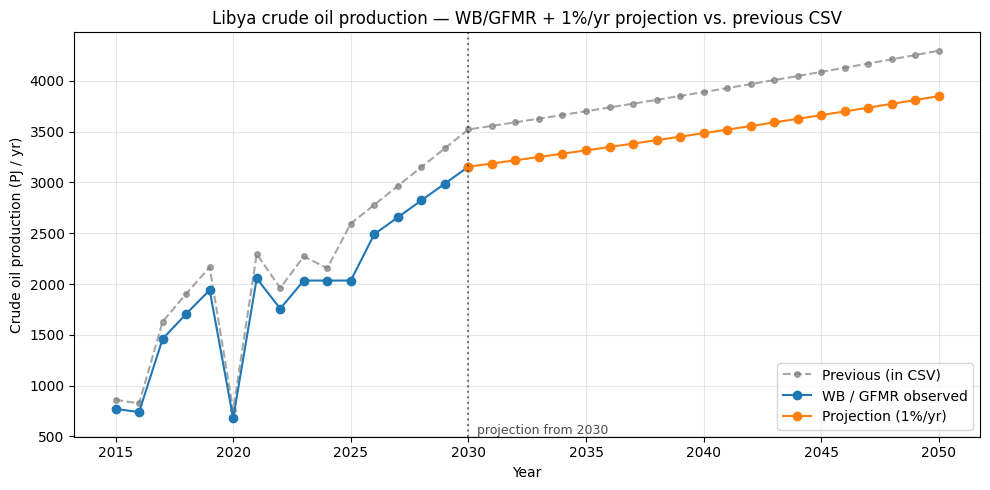

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

years_obs  = sorted(OIL_PRODUCTION_KBBLD)
years_proj = [y for y in years_sorted if y > last_obs_year]
years_full = years_obs + years_proj

old_curve = [float(old_values.loc[y]) if y in old_values.index else np.nan for y in years_full]
new_curve_obs  = [oil_production_pj[y] for y in years_obs]
new_curve_proj = [oil_production_pj[y] for y in [last_obs_year] + years_proj]  # bridge at last_obs_year

ax.plot(years_full, old_curve,
        label='Previous (in CSV)', linestyle='--', color='gray', marker='o', markersize=4, alpha=0.7)
ax.plot(years_obs, new_curve_obs,
        label='WB / GFMR observed', color='tab:blue', marker='o')
ax.plot([last_obs_year] + years_proj, new_curve_proj,
        label=f'Projection ({POST_OBS_GROWTH_RATE*100:.0f}%/yr)', color='tab:orange', marker='o')

ax.axvline(last_obs_year, color='black', linestyle=':', alpha=0.5)
ax.text(last_obs_year + 0.2, ax.get_ylim()[0], f' projection from {last_obs_year}',
        ha='left', va='bottom', fontsize=9, color='black', alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('Crude oil production (PJ / yr)')
ax.set_title('Libya crude oil production — WB/GFMR + 1%/yr projection vs. previous CSV')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()